# 휴먼 vs 매크로 행동 데이터 EDA

In [54]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import json
import numpy as np
import yaml
import seaborn as sns
import platform

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [55]:
# 가능한 한글 폰트 출력

import matplotlib.font_manager as fm

fonts = sorted(set(f.name for f in fm.fontManager.ttflist))

_fonts =  []
for font in fonts:
    if any(keyword in font.lower() for keyword in ["nanum", "noto", "malgun", "apple", "gothic"]):
        _fonts.append(font)
        print(font)

Century Gothic
Copperplate Gothic Bold
Copperplate Gothic Light
Franklin Gothic Book
Franklin Gothic Demi
Franklin Gothic Demi Cond
Franklin Gothic Heavy
Franklin Gothic Medium
Franklin Gothic Medium Cond
HYGothic-Extra
HYGothic-Medium
MS Gothic
Malgun Gothic
Noto Sans KR
Noto Serif KR
Showcard Gothic
Yu Gothic


In [56]:
# 노트북 세팅
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

# 한글 폰트 적용

system = platform.system()

if system == "Darwin":  # macOS
    font_candidates = ["Nanum Gothic", "AppleGothic"]
elif system == "Windows":
    font_candidates = ["Malgun Gothic"]
else:  
    font_candidates = ["Nanum Gothic", "DejaVu Sans"]

for _font in font_candidates:
    try:
        plt.rcParams["font.family"] = _font
        print(f"한글 폰트 적용: {_font}")
        break
    except Exception:
        continue
plt.rcParams["axes.unicode_minus"] = False

한글 폰트 적용: Malgun Gothic


## 1. 데이터 준비

In [57]:
# 데이터 경로 설정

ROOT = Path.cwd()

if(ROOT.name != "EDA"):
    raise Exception("데이터를 찾기 위해 작업 디렉토리 확인 필요")

DATA_DIR = Path("../../data/behavior")

print(ROOT)
print(DATA_DIR)

c:\Users\SSAFY\Desktop\ws\free\S14P31A203\services\ai\train\EDA
..\..\data\behavior


In [58]:
feature_config_path = Path("../../configs/feature_config.yaml")

with open(feature_config_path, "r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KR = feature_config["names_ko"]
EXCLUDE_COL = feature_config["exclude"] # trial_id, label, stage, selectedSeats 제외 -> not numberic

CLICK_FEATURES = FEATURE_GROUPS["click"]
MOUSE_FEATURES = FEATURE_GROUPS["mouse"]
KEYBOARD_FEATURES = FEATURE_GROUPS["keyboard"]

BEHAVIOR_FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]

print("행동 feature 개수:", len(BEHAVIOR_FEATURES))

행동 feature 개수: 44


In [59]:
# 행동 데이터 로드

def load_data(data_dir: Path) -> pd.DataFrame:
    """데이터 로드

    Args:
        data_dir (Path): 데이터 디렉토리 경로
    Returns:
        pd.DataFrame: 행동 데이터프레임
    """

    rows: list[dict] = []
    
    for path in sorted(data_dir.glob("trial_*.json")):

        data = json.loads(path.read_text(encoding="utf-8"))
        label = data.get("label", None)

        if(label is None):
            continue

        id = int(data.get("trialId"))
        summary = data.get("summary", {})
        feature = data.get("metrics", {})

        row = {
            "trial_id": id,
            "label": label,
        }

        if isinstance(summary, dict):
            row.update(summary)
        if isinstance(feature, dict):
            row.update(feature)
        
        rows.append(row)
    
    df = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    return df

df = load_data(DATA_DIR)

print("데이터 개수:", len(df))
display(df.head())


데이터 개수: 324


,trial_id,label,stage,durationMs,clickCount,eventCount,windowCount,selectedSeats,time_to_first_click_ms,time_from_element_visible_to_click_ms,time_from_element_clickable_to_click_ms,inter_click_interval_ms,click_sequence_consistency_score,click_position_repeat_rate,click_offset_from_element_center_px,click_offset_variance_px,double_click_rate,misclick_rate,reclick_rate,pre_click_mousemove_count,pre_click_hover_time_ms,pre_click_scroll_flag,immediate_post_render_click_rate,mouse_total_travel_distance_px,mouse_avg_speed_px_per_ms,mouse_max_speed_px_per_ms,mouse_speed_change_mean,mouse_acceleration_mean,mouse_jerk_mean,mouse_path_straightness_score,mouse_path_curvature_mean,mouse_direction_change_count,mouse_overshoot_flag,mouse_hover_dwell_time_ms,mouse_stop_segment_count,mousemove_event_rate,pre_click_mouse_path_pattern_300ms,pre_click_mouse_path_pattern_500ms,inter_element_move_interval_std_ms,edge_or_fixed_point_visit_rate,time_to_first_keydown_ms,inter_key_interval_ms_mean,inter_key_interval_ms_std,keydown_to_keyup_ms_mean,typing_total_duration_ms,typing_speed_cps,backspace_rate,correction_count,paste_flag,focus_to_submit_ms
0,1,macro,confirmed,2188.7,5,40,8,"[B3, B4]",1523.0,386.880000,386.880000,166.350000,1.000000,0.0,0.930801,0.022615,0.800000,0.000000,0.000000,9.800000,34.080000,0.0,0.8,1736.623385,0.793450,32.367655,7.323334,0.473873,0.064371,0.450931,0.282933,4,0,86.850000,6,9.137844,1147.5px | straight 0.49,1334.3px | straight 0.33,77.765593,0.0,35.3,24.716667,8.346140,19.471429,148.3,47.201618,0.0,0,0,289.6
1,2,human,confirmed,6458.4,9,323,26,"[B5, B4]",851.7,1513.637500,1513.637500,700.800000,0.875000,0.0,28.493302,646.669910,0.444444,0.111111,0.111111,27.444444,246.944444,0.0,0.0,2828.306989,0.437927,10.561944,0.445123,0.052016,0.004934,0.358283,0.206629,58,0,210.584000,20,46.296296,40.9px | straight 0.93,814.6px | straight 0.97,694.574215,0.0,558.8,192.150000,131.387845,117.814286,1152.9,6.071645,0.0,0,0,2887.7
2,3,human,confirmed,5969.8,7,322,23,"[B4, B5]",951.6,1510.433333,1510.433333,836.316667,0.833333,0.0,26.679236,122.389226,0.285714,0.142857,0.000000,33.000000,220.442857,0.0,0.0,1969.649553,0.329936,6.833317,0.267882,0.031645,0.003265,0.449383,0.248568,74,0,199.658333,12,50.587959,133.3px | straight 0.97,702.2px | straight 0.98,704.293103,0.0,622.1,153.960000,56.480779,127.083333,769.8,7.794232,0.0,0,0,2363.3
3,4,human,confirmed,5535.6,5,253,23,"[B4, B5]",1731.0,1456.900000,1456.900000,951.050000,1.000000,0.0,45.429430,1404.299006,0.200000,0.000000,0.000000,33.400000,207.200000,0.0,0.0,1939.123226,0.350300,5.180723,0.306412,0.036340,0.003624,0.451466,0.138800,35,0,193.380000,9,42.452489,81.9px | straight 0.94,593.8px | straight 0.99,674.567448,0.0,523.9,161.580000,87.159358,147.133333,807.9,7.426662,0.0,0,0,2125.2
4,5,human,confirmed,5874.0,6,276,22,"[B4, B5]",1533.5,1529.080000,1529.080000,868.060000,0.800000,0.0,29.553804,374.657158,0.333333,0.166667,0.000000,29.500000,178.900000,0.0,0.0,2085.415223,0.355025,4.651163,0.269461,0.032168,0.003403,0.428887,0.206689,47,0,175.150000,13,43.752128,92.9px | straight 0.98,626.0px | straight 0.99,726.495620,0.0,468.5,156.800000,51.045117,129.183333,784.0,7.653061,0.0,0,0,2587.7


## 2. 데이터 전처리

In [60]:
# pre_click_mouse_path 문자열 패턴에서 거리와 직선성 추출

import pandas as pd

def add_pre_click_path_features(df: pd.DataFrame) -> None:
    """pre_click_mouse_path 문자열 패턴에서 거리와 직선성을 추출하여 feature로 추가
    
    Args:
        df (pd.DataFrame): 행동 데이터프레임
    """

    for sec in [300, 500]:
        col = f"pre_click_mouse_path_pattern_{sec}ms"

        if col not in df.columns:
            continue

        parts = (
            df[col]
            .fillna("")
            .astype(str)
            .str.split("|", n=1, expand=True)
        )

        distance_text = (
            parts[0]
            .str.replace("px", "", regex=False)
            .str.strip()
        )

        straightness_text = (
            parts[1]
            .str.replace("straight", "", regex=False)
            .str.strip()
        )

        distance_col = f"pre_click_path_{sec}ms_total_distance_px"
        straightness_col = f"pre_click_path_{sec}ms_straightness"

        insert_idx = df.columns.get_loc(col)

        distance_value = pd.to_numeric(distance_text, errors="coerce")
        straightness_value = pd.to_numeric(straightness_text, errors="coerce")

        df.drop(columns=[col], inplace=True)

        df.insert(insert_idx, distance_col, distance_value)
        df.insert(insert_idx + 1, straightness_col, straightness_value)
        
add_pre_click_path_features(df)

## 3. 기본 분석

In [61]:
# 행동 데이터 통계 요약

def feature_summary(df: pd.DataFrame) -> pd.DataFrame:
    """행동 데이터 통계 정보 요약 & 휴먼, 매크로 비교
    
    Args:
        df (pd.DataFrame): 행동 데이터프레임

    Returns:
        pd.DataFrame: 행동 feature 통계 요약 데이터프레임
    """

    n_rows = max(1, int(df.shape[0]))

    rows: list[dict] = []

    for feature in df.columns:
        if feature in EXCLUDE_COL:
            continue
        s = df[feature].dropna()

        rows.append(
            {
                "feature_ko": FEATURE_NAME_KR.get(feature),
                "count": int(s.shape[0]),
                "mean": float(s.mean()) if s.shape[0] else np.nan,
                "min": float(s.min()) if s.shape[0] else np.nan,
                "max": float(s.max()) if s.shape[0] else np.nan,
            }
        )

    return pd.DataFrame(rows)

human_df = df[df["label"] == "human"]
macro_df = df[df["label"] == "macro"]

human_summary = feature_summary(human_df)
macro_summary = feature_summary(macro_df)

compare_summary = human_summary.merge(
    macro_summary,
    on=["feature_ko"],
    suffixes=("_human", "_macro")
)

compare_summary["mean_diff"] = (
    abs(compare_summary["mean_macro"] - compare_summary["mean_human"])
)

compare_summary = compare_summary[
    [
        "feature_ko",
        "mean_diff",
        "mean_human",
        "mean_macro",
        "min_human",
        "min_macro",
        "max_human",
        "max_macro",
        "count_human",
        "count_macro",
    ]
]

print("휴먼 데이터 수 : ", human_df.shape[0])
print("매크로 데이터 수 : ", macro_df.shape[0])

print("\n행동 feature 통계 요약 비교:")
display(compare_summary)


휴먼 데이터 수 :  160
매크로 데이터 수 :  164

행동 feature 통계 요약 비교:


,feature_ko,mean_diff,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro
0,페이지 체류 시간,2770.280732,6826.435000,4056.154268,4636.500000,1957.800000,17895.600000,7161.700000,160,164
1,클릭 수,0.468750,5.468750,5.000000,5.000000,5.000000,9.000000,5.000000,160,164
2,전체 이벤트 수,257.939787,310.531250,52.591463,163.000000,30.000000,692.000000,90.000000,160,164
3,이벤트 집계 구간 수,11.730335,26.193750,14.463415,17.000000,7.000000,69.000000,27.000000,160,164
4,첫 클릭 시간,38.376585,1621.915000,1583.538415,745.100000,1247.000000,5950.100000,2130.000000,160,164
5,노출 후 클릭,915.252743,1832.224329,916.971585,1119.720000,295.040000,6103.450000,1838.760000,160,164
6,활성 후 클릭,915.252743,1832.224329,916.971585,1119.720000,295.040000,6103.450000,1838.760000,160,164
7,클릭 간격,549.671062,1167.738287,618.067226,647.160000,128.900000,2576.650000,1332.475000,160,164
8,순서 일관성,0.048296,0.951704,1.000000,0.666667,1.000000,1.000000,1.000000,160,164
9,좌표 반복률,0.002865,0.002865,0.000000,0.000000,0.000000,0.166667,0.000000,160,164


### 3-1 데이터 분포 시각화 (박스 플롯)

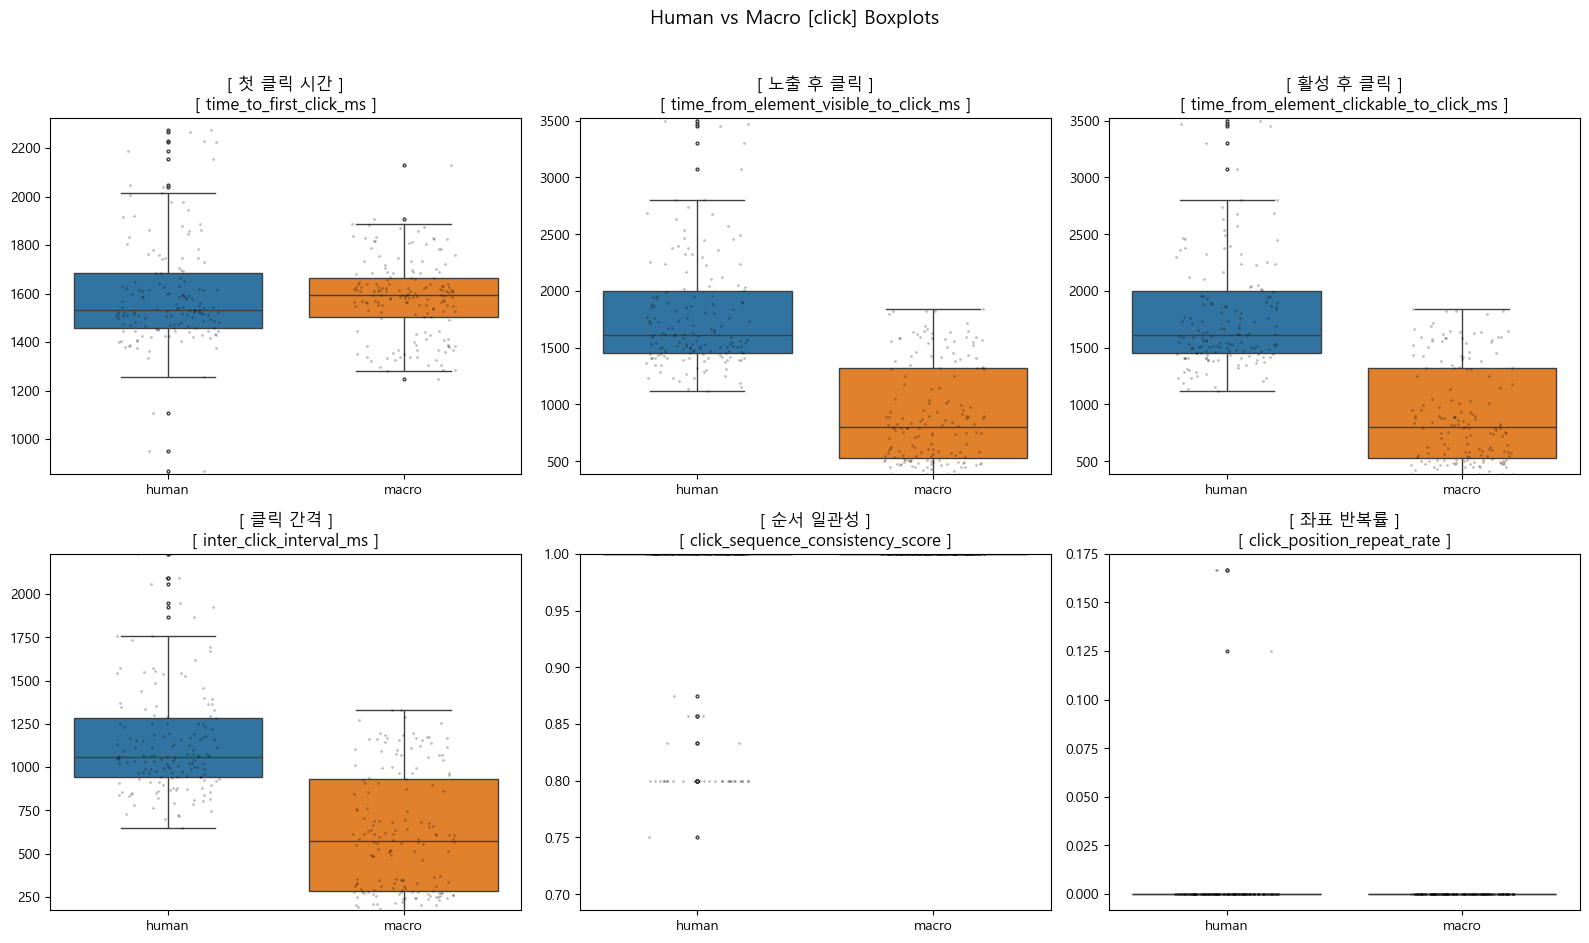

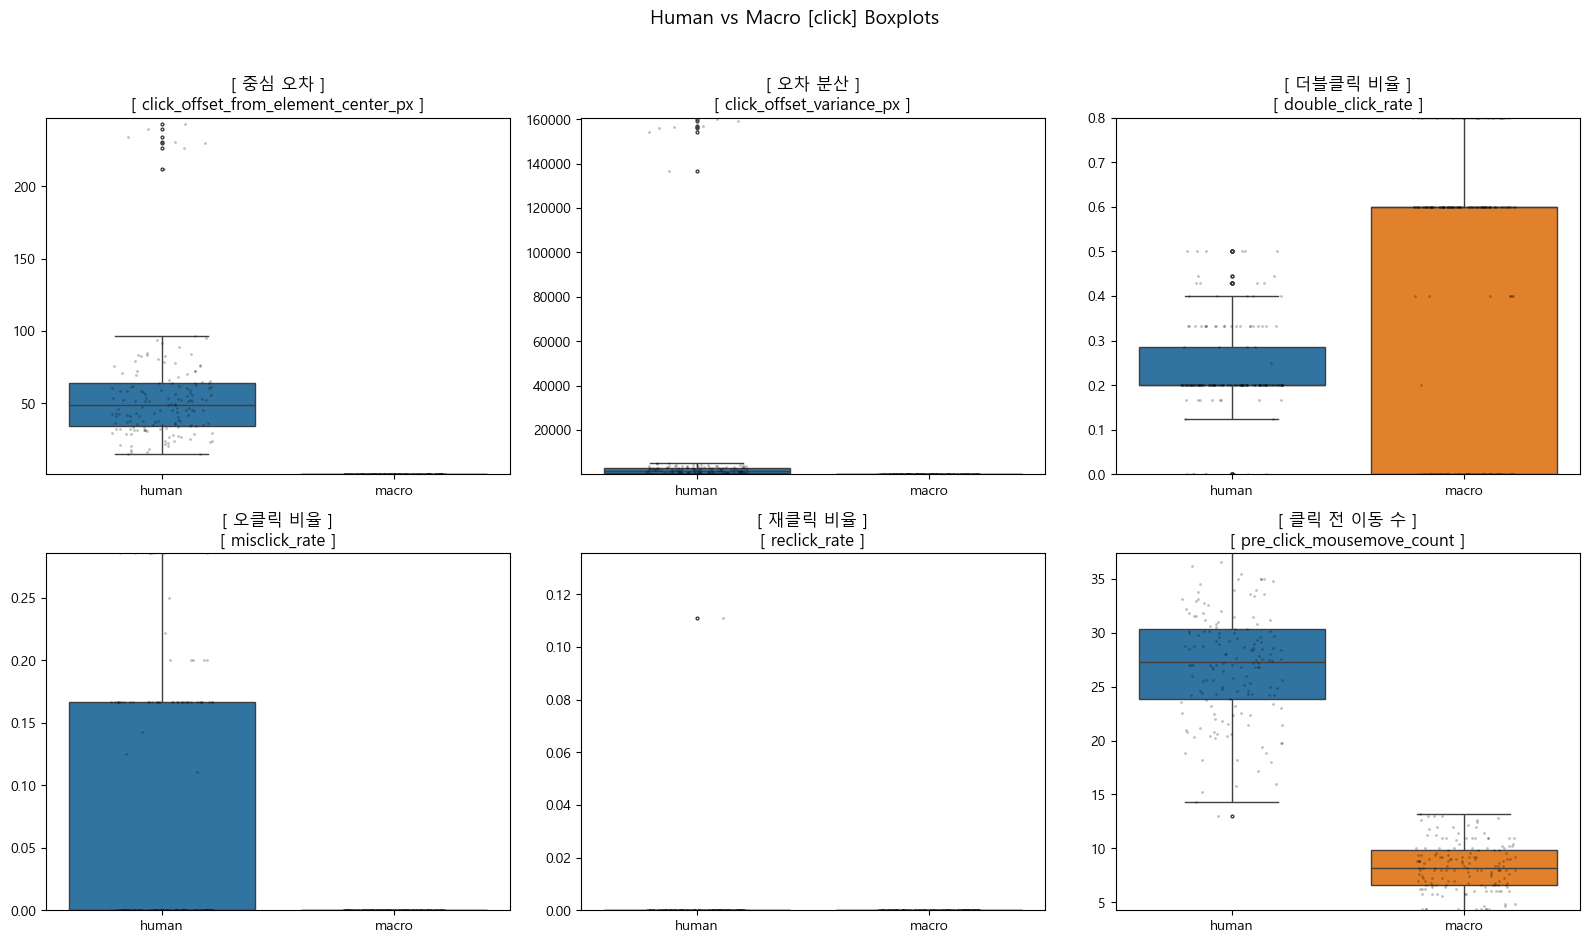

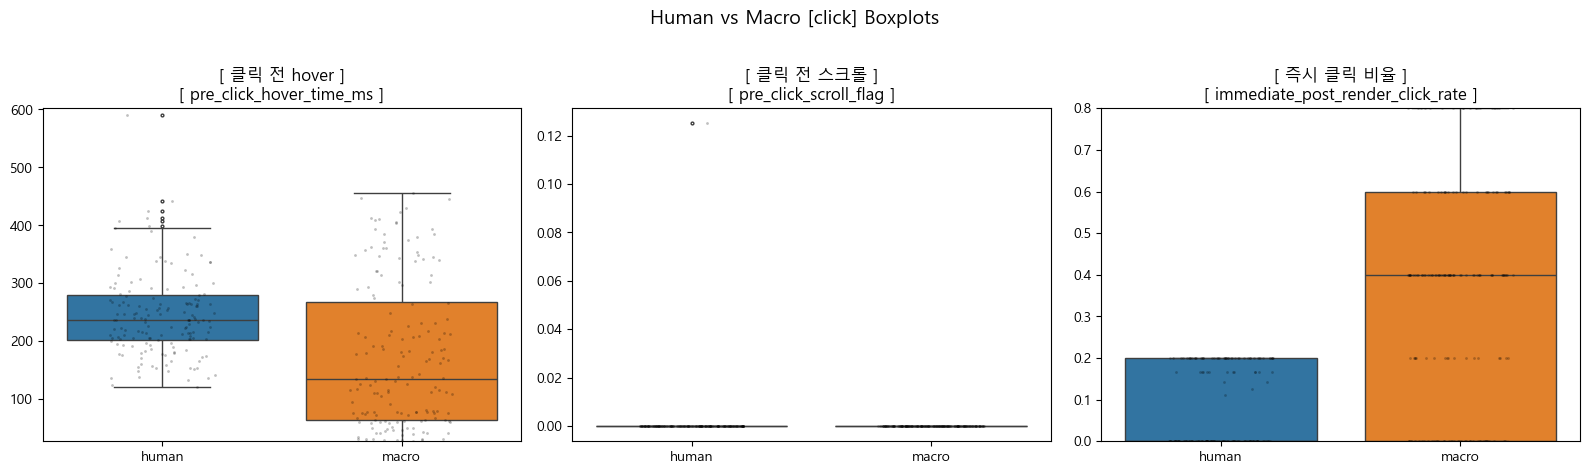

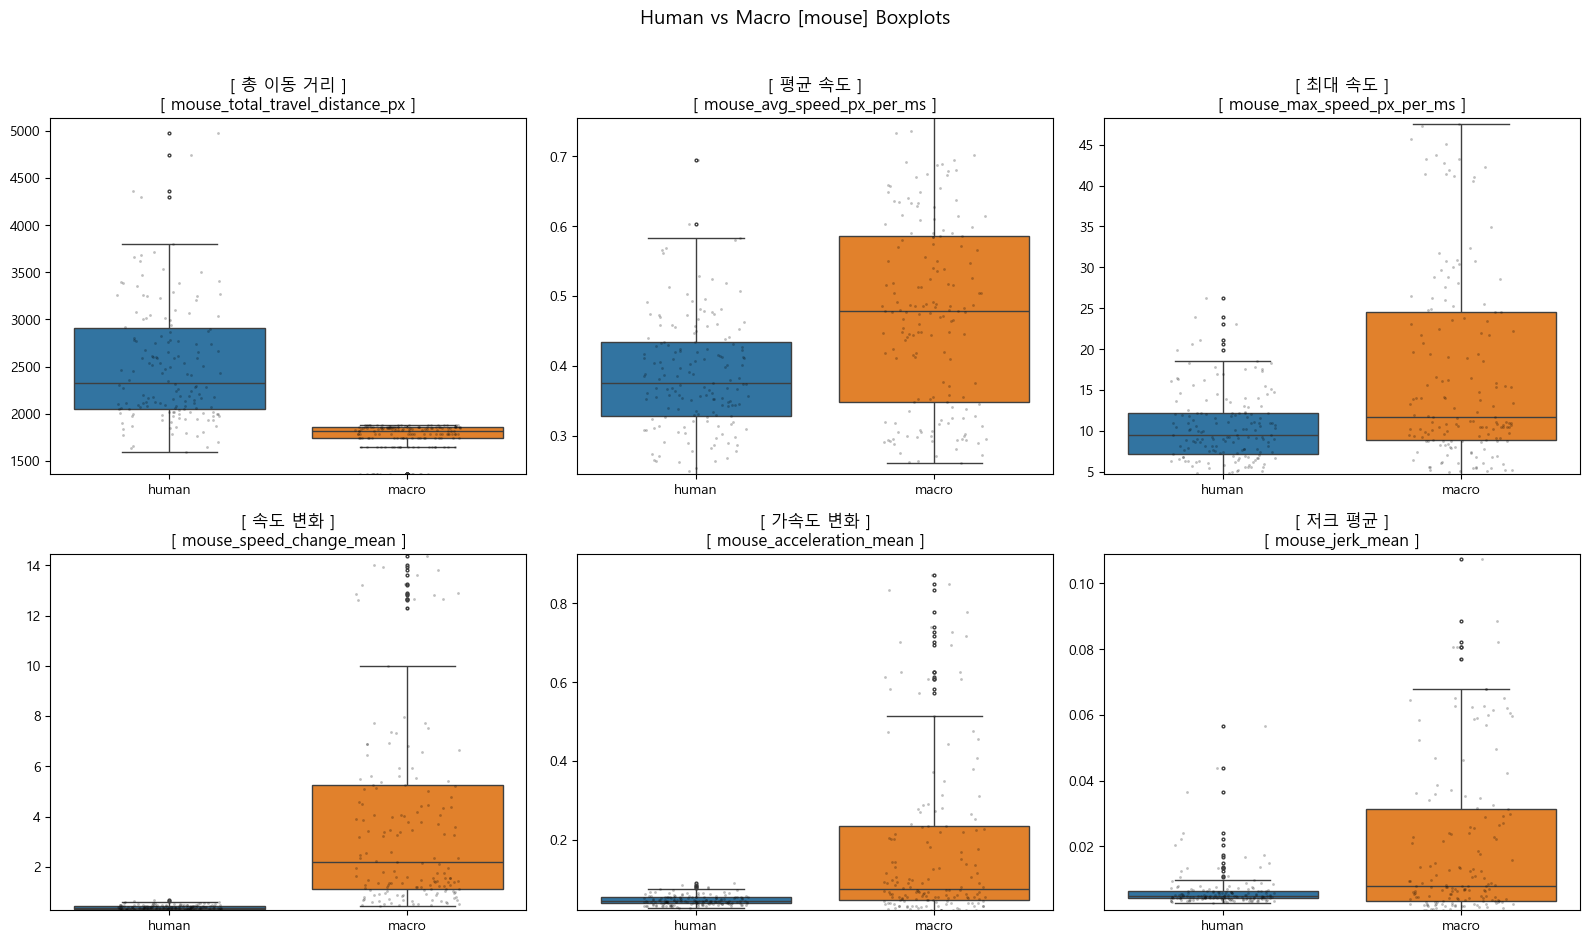

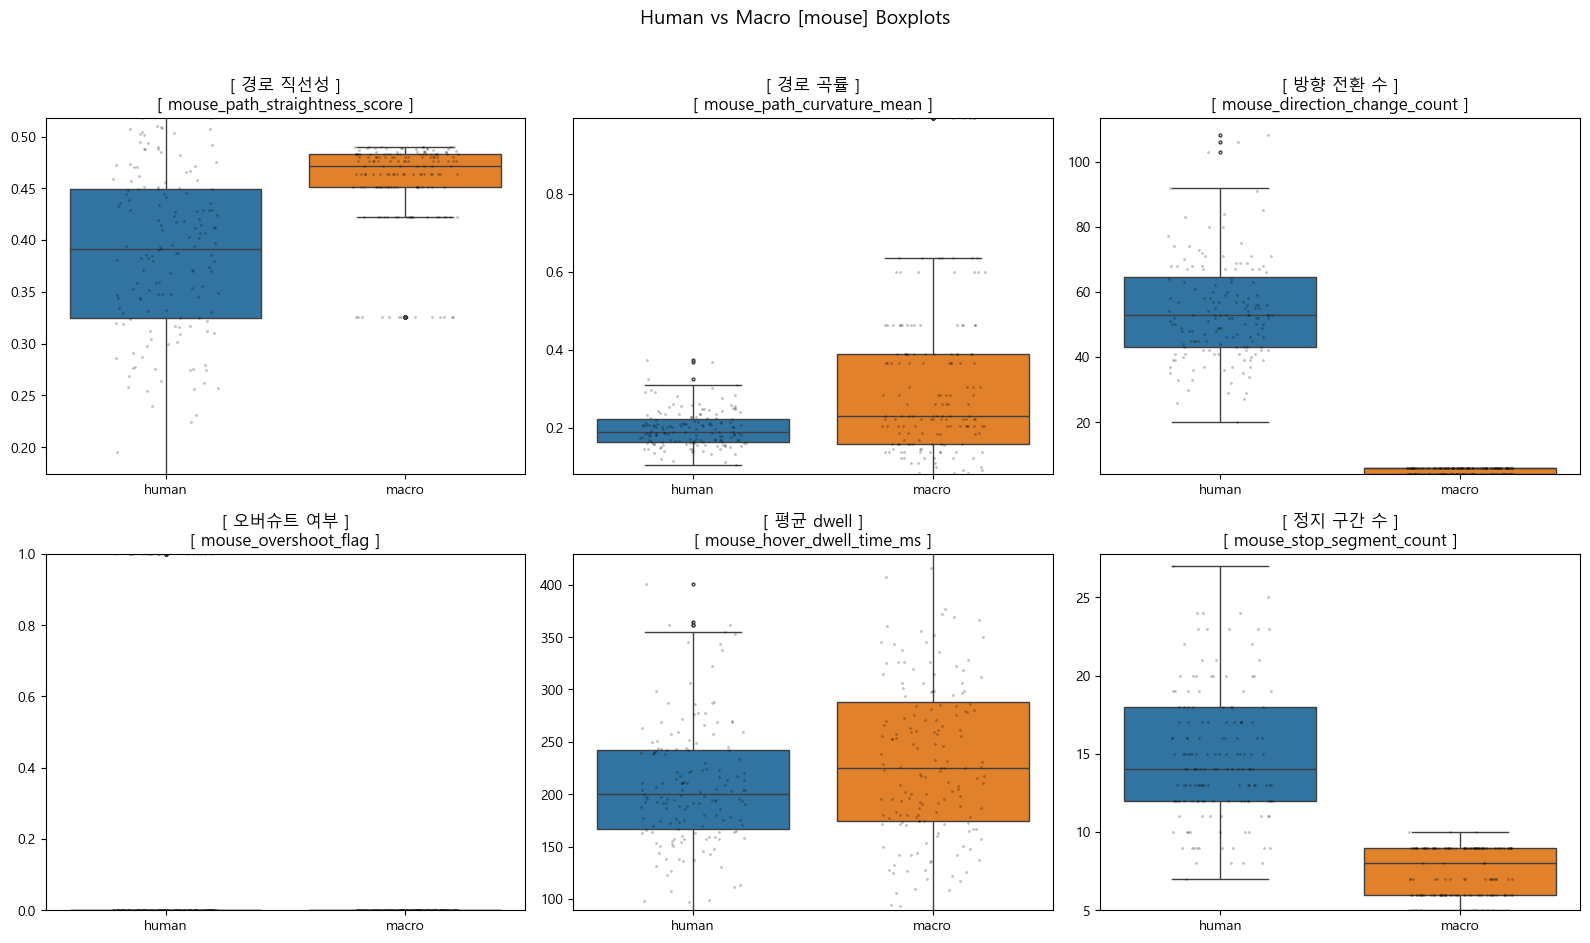

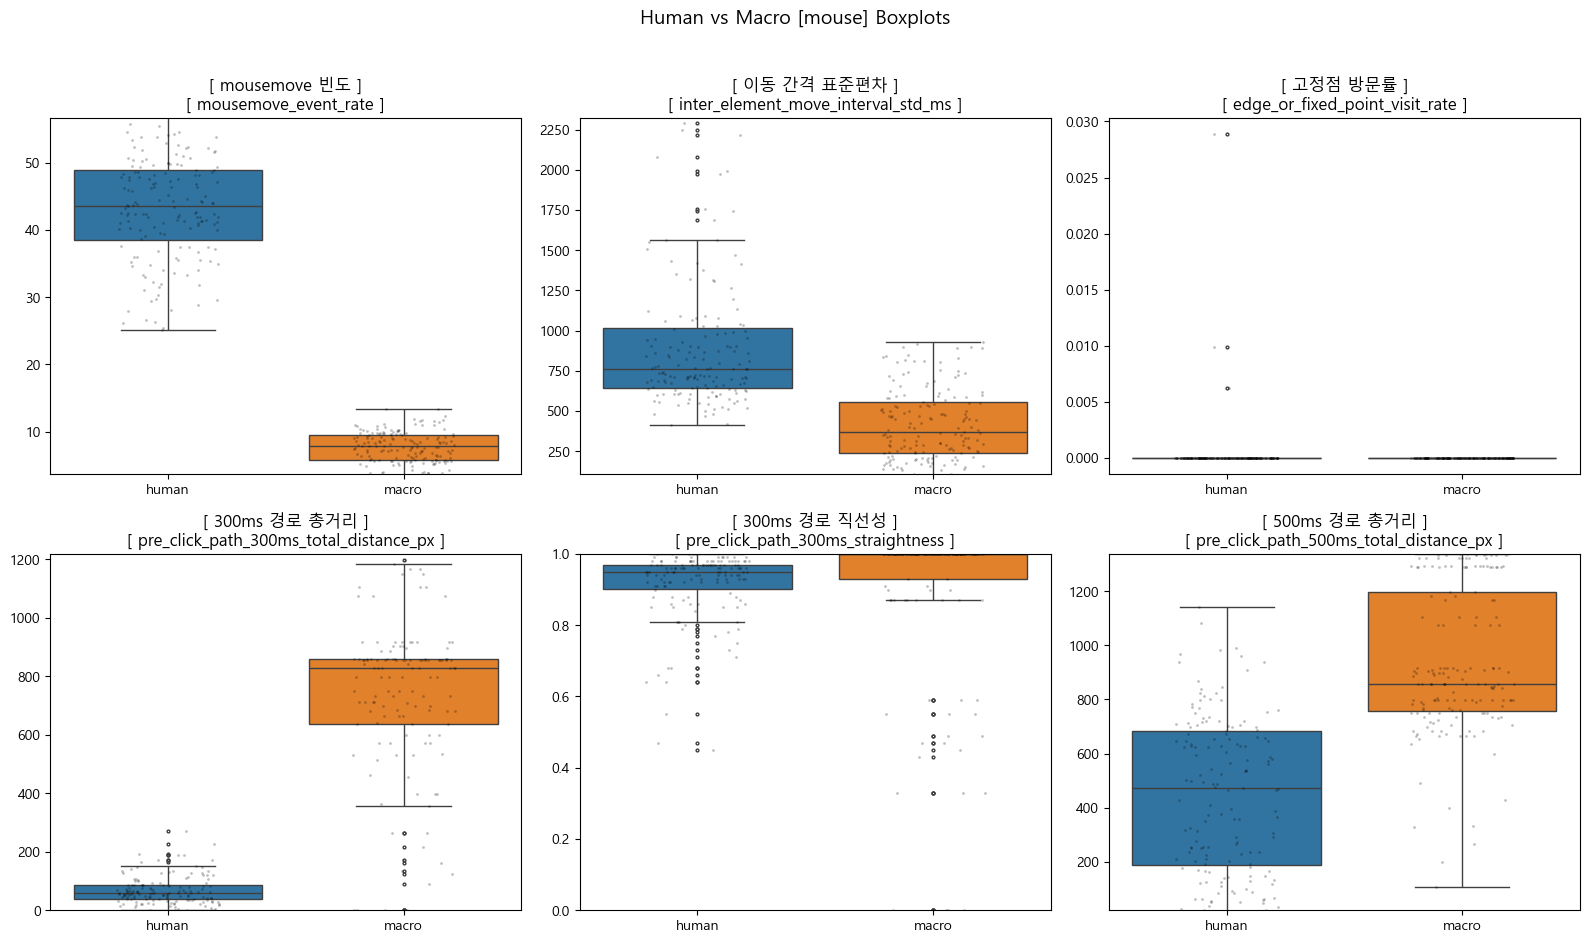

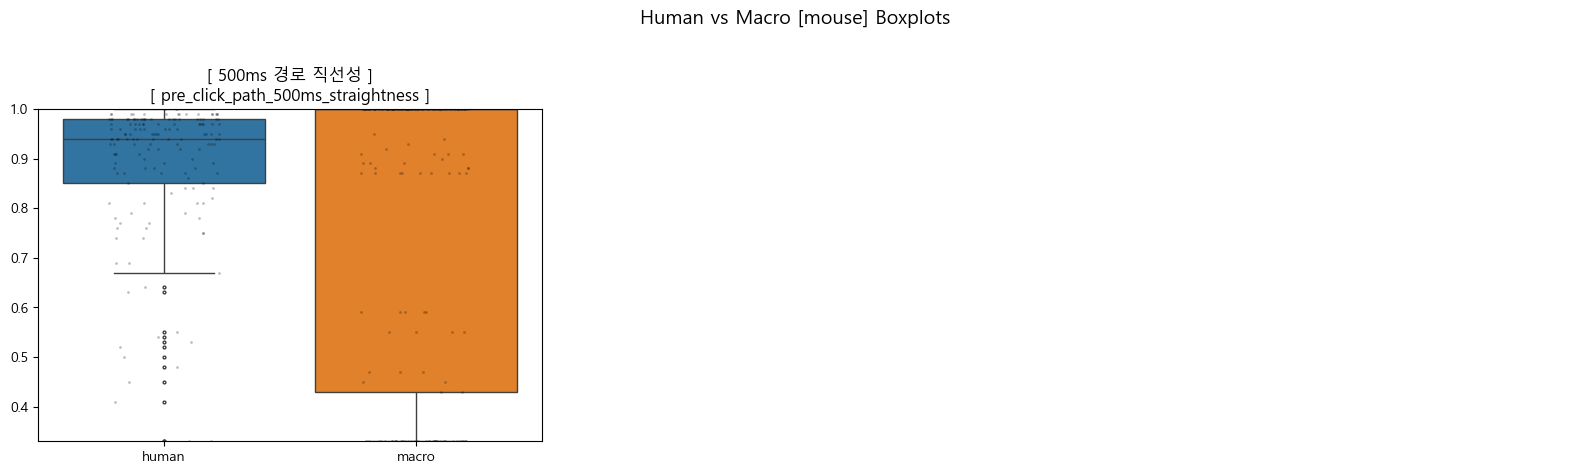

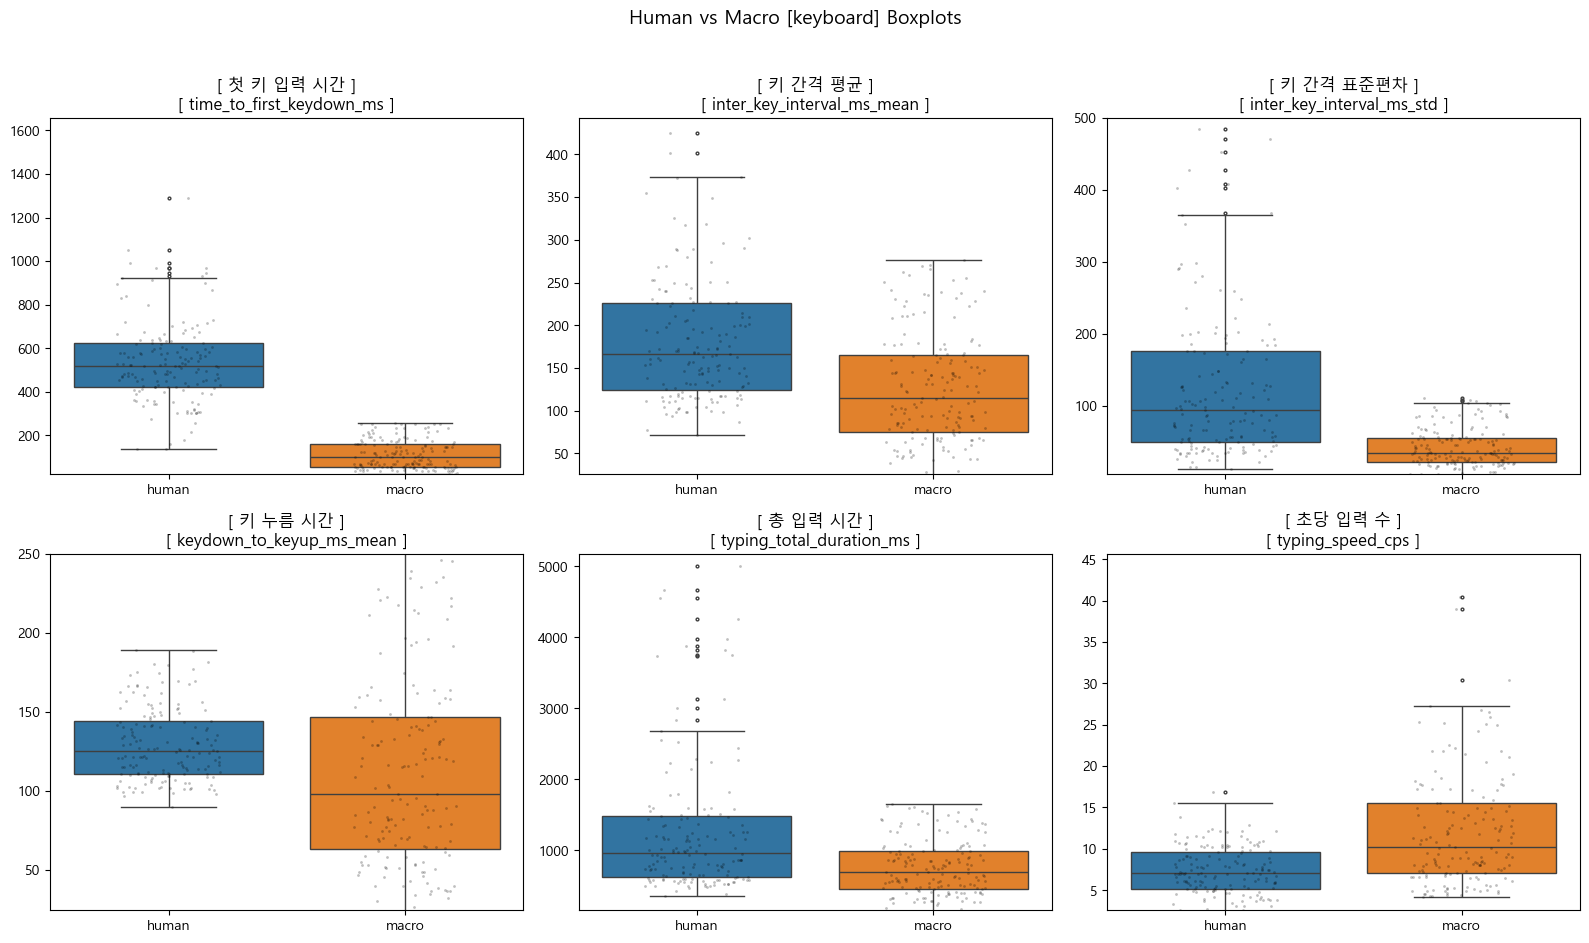

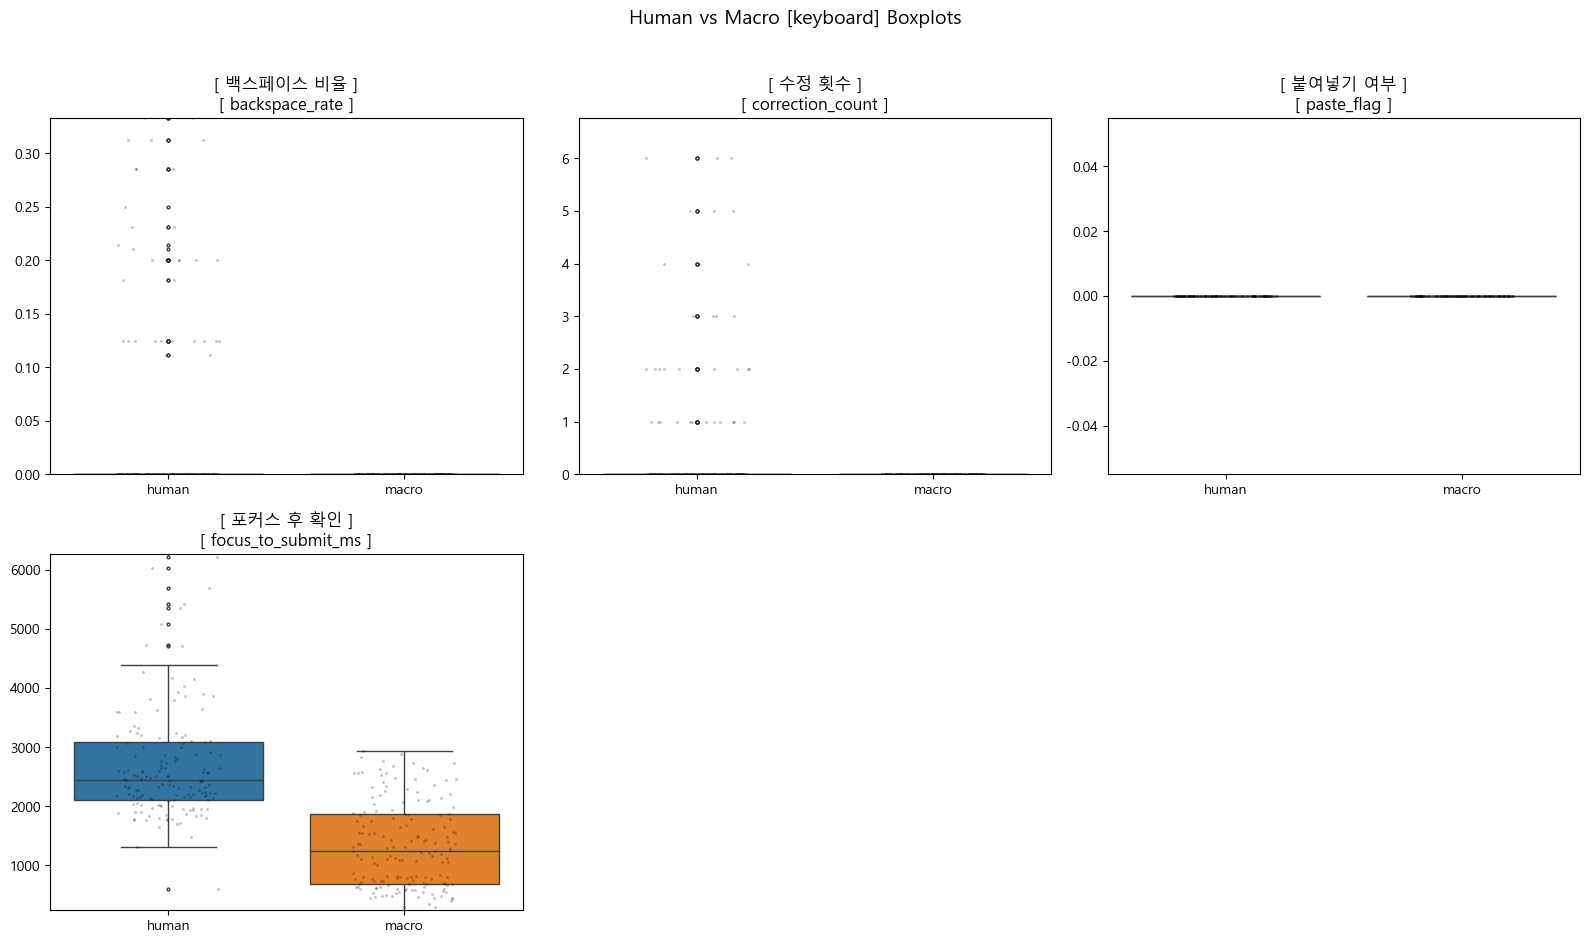

In [62]:
N_COLS = 3
N_FEATURES = 6
MAX_STRIP_PER_LABEL = 300

def draw_boxplot(group: str, features: list[str]) -> None:
    """행동 feature 그룹별 boxplot 그리기
    
    Args:
        group (str): feature 그룹명
        features (list[str]): feature 이름 리스트
    """

    features =  [feature for feature in features if feature not in EXCLUDE_COL]

    if not features:
        print("skip:", group)
        return
    
    for start in range(0, len(features), N_FEATURES):
        subset = features[start: start + N_FEATURES]

        rows = int(np.ceil(len(subset) / N_COLS))

        fig, axes = plt.subplots(rows, N_COLS, figsize=(16, 4.6 * rows))

        axes = np.array(axes).reshape(rows, N_COLS)

        for i, feature in enumerate(subset):
            r = i // N_COLS
            c = i % N_COLS
            ax = axes[r, c]

            s = pd.to_numeric(df[feature], errors="coerce")

            plot_df = pd.DataFrame(
                {
                    "label": df["label"],
                    "value": s,
                }
            ).dropna()

            feature_ko = FEATURE_NAME_KR.get(feature, feature)

            if plot_df.empty:
                ax.set_title(f"[ {feature_ko} ]\n[ {feature} ]")
                ax.axis("off")
                continue

            sns.boxplot(
                data=plot_df,
                x="label",
                y="value",
                hue="label",
                order=["human", "macro"],
                hue_order=["human", "macro"],
                legend=False,
                dodge=False,
                ax=ax,
                fliersize=2,
            )

            strip_parts = []

            for label in ["human", "macro"]:
                part = plot_df[plot_df["label"] == label]

                if part.empty:
                    continue

                strip_parts.append(
                    part.sample(
                        min(len(part), MAX_STRIP_PER_LABEL),
                        random_state=42,
                    )
                )

            if strip_parts:
                strip_df = pd.concat(strip_parts, ignore_index=True)

                sns.stripplot(
                    data=strip_df,
                    x="label",
                    y="value",
                    ax=ax,
                    color="black",
                    alpha=0.25,
                    size=2,
                    jitter=0.22,
                )

            q_low = plot_df["value"].quantile(0.01)
            q_high = plot_df["value"].quantile(0.99)
            if q_high > q_low:
                ax.set_ylim(q_low, q_high)

            ax.set_title(f"[ {feature_ko} ]\n[ {feature} ]")
            ax.set_xlabel("")
            ax.set_ylabel("")

        total_axes = rows * N_COLS

        for j in range(len(subset), total_axes):
            r = j // N_COLS
            c = j % N_COLS
            axes[r, c].axis("off")

        fig.suptitle(
            f"Human vs Macro [{group}] Boxplots",
            y=1.02,
            fontsize=14,
        )

        plt.tight_layout()
        plt.show()


for group, features in FEATURE_GROUPS.items():
    draw_boxplot(group, features)

### 3-2 상관관계 분석

### 3-3 PCA

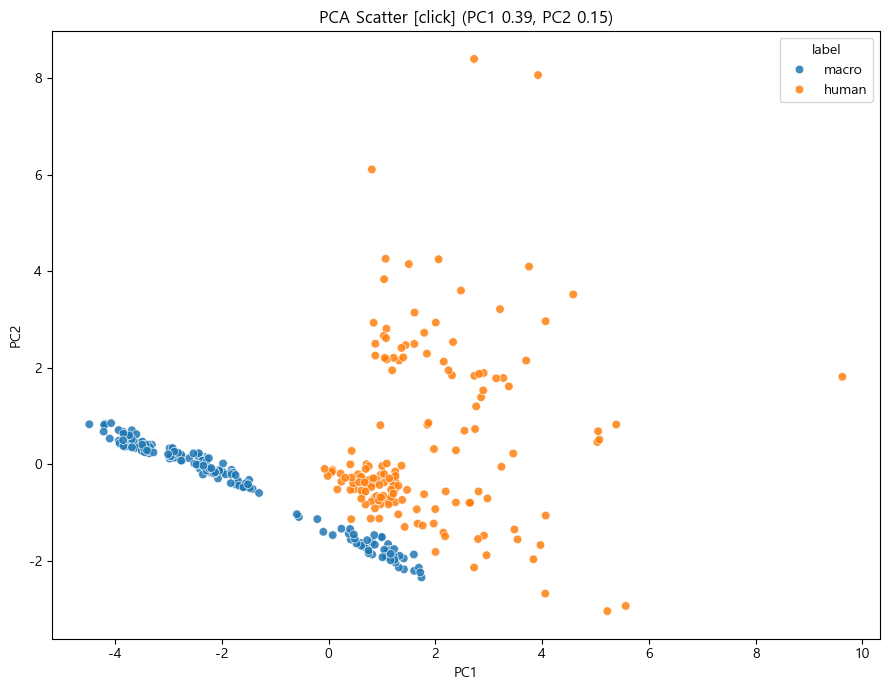

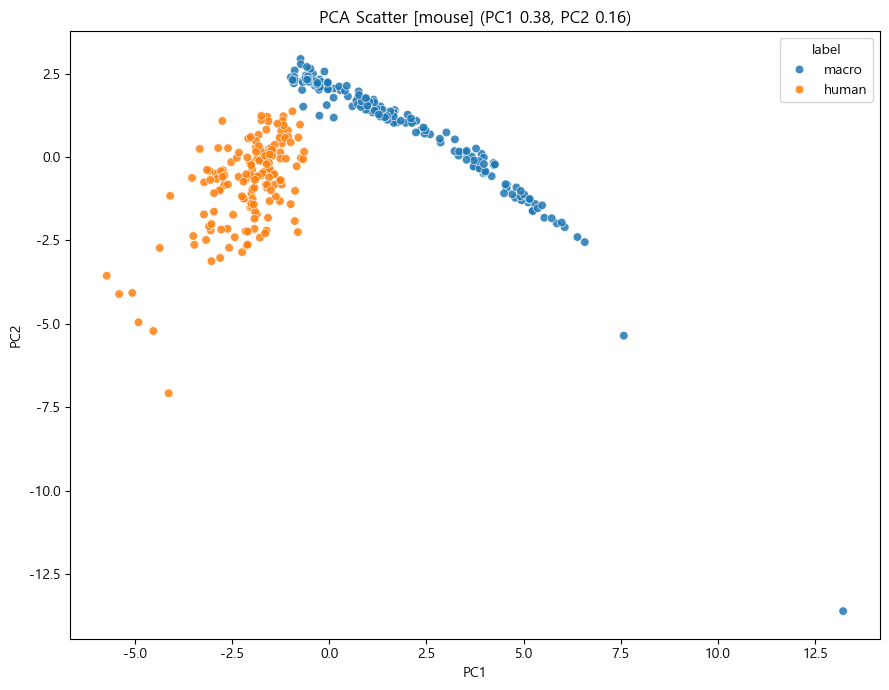

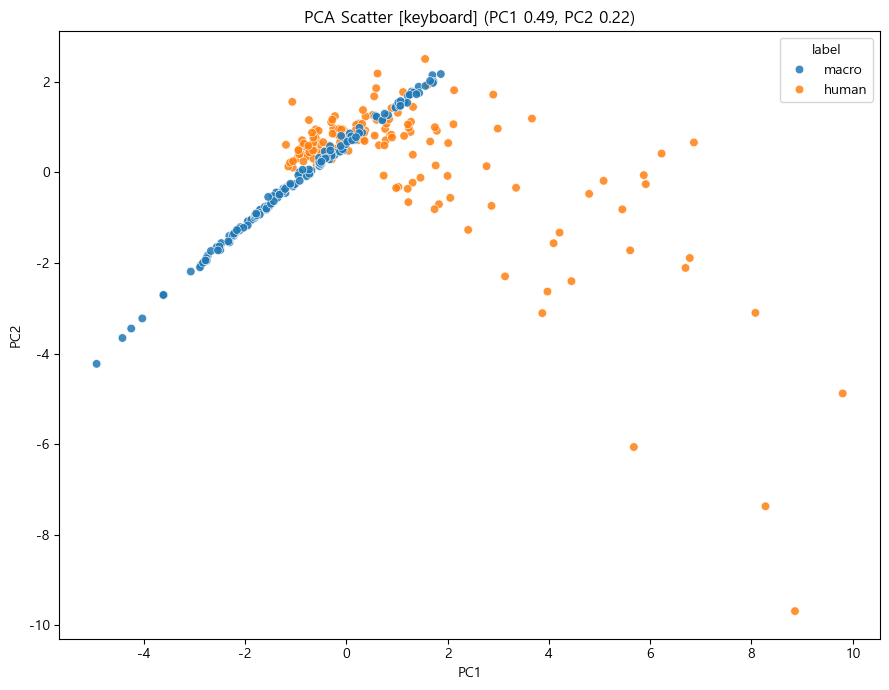

In [63]:
def draw_pca_scatter(title: str, features: list[str]) -> None:
    """PCA scatter plot 그리기
    
    Args:
        title (str): plot 제목
        features (list[str]): PCA에 사용할 feature 이름 리스트
    """

    features = [feature for feature in features if feature not in EXCLUDE_COL]

    if len(features) < 2:
        print("skip PCA:", title)
        return

    X = df[features].apply(pd.to_numeric, errors="coerce")

    features = [feature for feature in features if X[feature].notna().sum() > 0]

    if len(features) < 2:
        print("skip PCA:", title)
        return

    X = X[features]

    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=2, random_state=42)),
        ]
    )

    xy = pipe.fit_transform(X)
    pca = pipe.named_steps["pca"]
    explained = pca.explained_variance_ratio_

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        x=xy[:, 0],
        y=xy[:, 1],
        hue=df["label"],
        s=38,
        alpha=0.85,
    )

    plt.title(
        f"PCA Scatter [{title}] "
        f"(PC1 {explained[0]:.2f}, PC2 {explained[1]:.2f})"
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

for group, features in FEATURE_GROUPS.items():
    draw_pca_scatter(group, features)

## 4. Personal EDA

## 5. 분석 리포트